# Wind Indicator for NYB
Last edited by L Gruenburg on 10/24/2025

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import geopandas as gpd
import pandas as pn
from windrose import WindroseAxes
import matplotlib.colors as colors
import numpy as np
import matplotlib.ticker as mtick
import argparse
import math

In [2]:
# Read in previous indicator report's data
wind_all2023 = pn.read_csv('/Users/lauragruenburg/Desktop/NYB_Indicators_Calculations/Final_Timeseries_Figures/Timeseries_Files_2023/Wind_buoy2_Aug_14_2023.csv')

In [3]:
# get just the variables we want
wind = wind_all2023[['time','wind_dir','wind_spd']]

In [4]:
# make time datetime so we can use it
wind.loc[:,'time'] = pn.to_datetime(wind['time'])

In [5]:
# some of the rows had time zoen some didnt and that was making things complicated and annoying so here we make all rows consistent
wind.loc[:,'time'] = wind['time'].apply(lambda x: x.tz_localize(None)) 


In [6]:
# here we get 2023 and 2024 as we downloaded from the buoy website
wind2023 = pn.read_csv('~/Downloads/wind_nyh_2023.txt', sep= '\s+', engine='python', header = [0,1])
wind2024 = pn.read_csv('~/Downloads/wind_nyh2024.csv', sep = '\s+', engine = 'python', header = [0,1])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_11789/3132999942.py:2: SyntaxWarning: invalid escape sequence '\s'
  wind2023 = pn.read_csv('~/Downloads/wind_nyh_2023.txt', sep= '\s+', engine='python', header = [0,1])
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_11789/3132999942.py:3: SyntaxWarning: invalid escape sequence '\s'
  wind2024 = pn.read_csv('~/Downloads/wind_nyh2024.csv', sep = '\s+', engine = 'python', header = [0,1])


In [7]:
# January was monthly files on the buoy website, the most recent I could get for the 2025 report was July
wind2025_jan = pn.read_csv('~/Downloads/wind_nyh_jan2025.txt', sep= '\s+', engine='python', header = [0,1])
wind2025_feb = pn.read_csv('~/Downloads/wind_nyh_feb2025.txt', sep= '\s+', engine='python', header = [0,1])
wind2025_mar = pn.read_csv('~/Downloads/wind_nyh_mar2025.csv', sep= '\s+', engine='python', header = [0,1])
wind2025_apr = pn.read_csv('~/Downloads/wind_nyh_apr2025.csv', sep= '\s+', engine='python', header = [0,1])
wind2025_may = pn.read_csv('~/Downloads/wind_nyh_may2025.csv', sep= '\s+', engine='python', header = [0,1])
wind2025_jun = pn.read_csv('~/Downloads/wind_nyh_jun2025.csv', sep= '\s+', engine='python', header = [0,1])
wind2025_jul = pn.read_csv('~/Downloads/wind_nyh_jul2025.csv', sep= '\s+', engine='python', header = [0,1])
wind2025 = pn.concat([wind2025_jan, wind2025_feb, wind2025_mar, wind2025_apr, wind2025_may, wind2025_jun, wind2025_jul])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_11789/818356114.py:2: SyntaxWarning: invalid escape sequence '\s'
  wind2025_jan = pn.read_csv('~/Downloads/wind_nyh_jan2025.txt', sep= '\s+', engine='python', header = [0,1])
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_11789/

In [8]:
# double column names not great, here we drop one row of them
wind2023_drop = wind2023
wind2023_drop.columns = wind2023_drop.columns.droplevel(1)

In [9]:
wind2024_drop = wind2024
wind2024_drop.columns = wind2024_drop.columns.droplevel(1)

In [10]:
wind2025_drop = wind2025
wind2025_drop.columns = wind2025_drop.columns.droplevel(1)

In [11]:
# renaming some columns to make it easier to convert to datetime
wind2023_drop = wind2023_drop.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'min'})
wind2024_drop = wind2024_drop.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'min'})
wind2025_drop = wind2025_drop.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'min'})


In [12]:
# convert time to dateteime
wind2023_drop['time'] = pn.to_datetime(wind2023_drop[['year', 'month', 'day','hour']], yearfirst = True)
wind2024_drop['time'] = pn.to_datetime(wind2024_drop[['year', 'month', 'day','hour']], yearfirst = True)
wind2025_drop['time'] = pn.to_datetime(wind2025_drop[['year', 'month', 'day','hour']], yearfirst = True)

In [13]:
# rename variables for consistency
wind2023_drop = wind2023_drop.rename(columns = {'WSPD': 'wind_spd', 'WDIR': 'wind_dir'})
wind2024_drop = wind2024_drop.rename(columns = {'WSPD': 'wind_spd', 'WDIR': 'wind_dir'})
wind2025_drop = wind2025_drop.rename(columns = {'WSPD': 'wind_spd', 'WDIR': 'wind_dir'})

In [14]:
# need data from august through dec for 2023
wind2023_drop_aug = wind2023_drop[wind2023_drop.month > 7]

In [15]:
# put all the data together
wind_for_clim = pn.concat([wind, wind2023_drop_aug, wind2024_drop, wind2025_drop], join='inner', ignore_index=True)

In [16]:
# get rid of bad data in direction
wind_for_clim_clean = wind_for_clim[wind_for_clim.wind_dir<361].reset_index(drop = True)

In [17]:
# get rid of bad data in speed
wind_for_clim_clean = wind_for_clim_clean[wind_for_clim_clean.wind_spd<80].reset_index(drop = True)

In [18]:
# all the wind data with the index set to the date makes things easier for plotting
wind_all = wind_for_clim_clean
wind_all = wind_all.set_index("time")
wind_all

/opt/anaconda3/envs/indicators_env/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,wind_dir,wind_spd
time,,
2008-10-30 17:50:00,308.0,8.2
2008-10-30 18:50:00,314.0,8.3
2008-10-30 19:50:00,303.0,7.1
2008-10-30 20:50:00,324.0,8.1
2008-10-30 21:50:00,314.0,7.9
...,...,...
2025-07-31 23:00:00,35.0,7.5
2025-07-31 23:00:00,34.0,8.5
2025-07-31 23:00:00,35.0,8.3


In [19]:
# Extract the day of the year
wind_for_clim_clean['day_of_year'] = pn.to_datetime(wind_for_clim_clean['time']).dt.dayofyear

# Group by 'day_of_year' and calculate the mean of 'value'
wind_clim = wind_for_clim_clean.groupby('day_of_year').mean(['wind_spd', 'wind_dir'])

In [20]:
wind_clim

,wind_dir,wind_spd
day_of_year,,
1,222.213962,7.394651
2,230.692600,7.550095
3,203.902174,7.963315
4,237.229015,7.244434
5,214.067029,7.983786
...,...,...
362,213.100635,6.377697
363,202.000910,6.090719
364,184.696558,6.292391


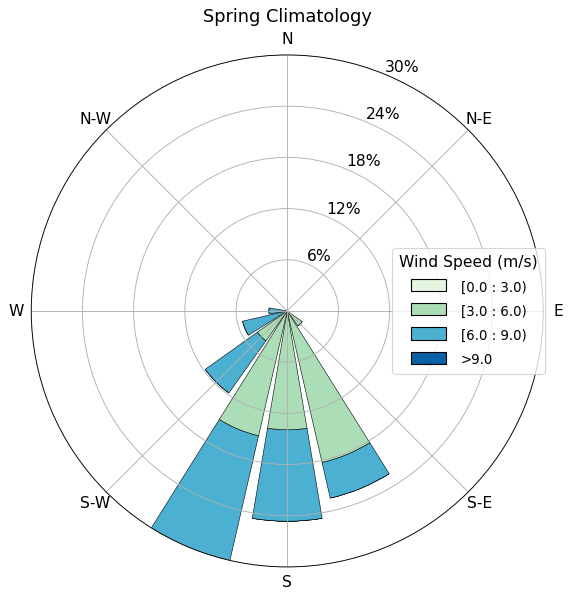

In [24]:
# SPRING climatology plot

def truncate_colormap(color, minval=0.0, maxval=1.0, n=100):
    cmap = plt.colormaps.get_cmap(color)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmap = truncate_colormap('GnBu', 0.1, 0.9)

#SPRING

ws = np.squeeze(wind_clim['wind_spd'][60:152].to_numpy())
wd = np.squeeze(wind_clim['wind_dir'][60:152].to_numpy())

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='right', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Spring Climatology', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=12) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

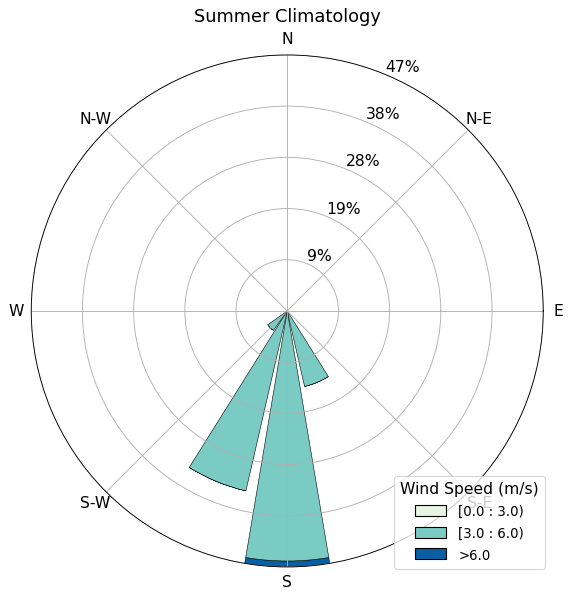

In [25]:
#SUMMER climatology plot

ws = np.squeeze(wind_clim['wind_spd'][152:243].to_numpy())
wd = np.squeeze(wind_clim['wind_dir'][152:243].to_numpy())

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='lower right', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Summer Climatology', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=14) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

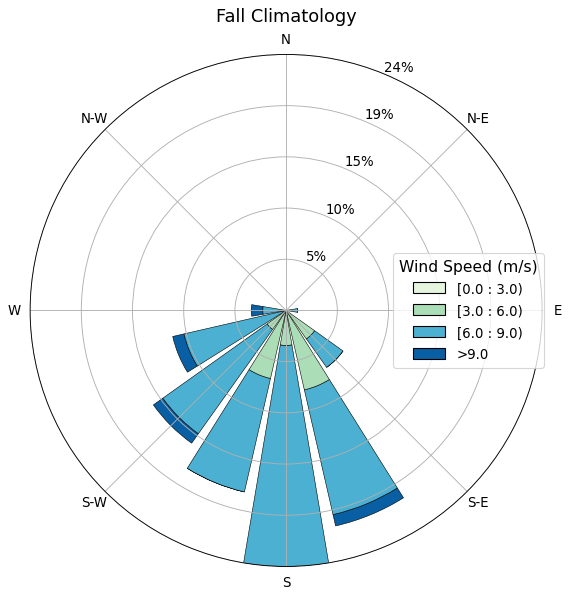

In [212]:
#FALL climatology plot

ws = np.squeeze(wind_clim['wind_spd'][243:334].to_numpy())
wd = np.squeeze(wind_clim['wind_dir'][243:334].to_numpy())

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='right', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Fall Climatology', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=12) # controls default text sizes
plt.rc('axes', titlesize=12) # fontsize of the axes title
plt.rc('axes', labelsize=12) # fontsize of the x and y labels
plt.rc('xtick', labelsize=12) # fontsize of the tick labels
plt.rc('ytick', labelsize=12) # fontsize of the tick labels

plt.show()

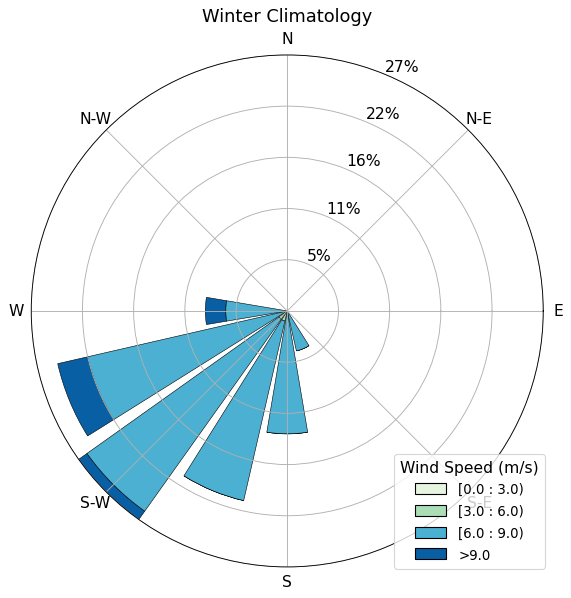

In [36]:
#WINTER climatology plot

ws = np.concat([np.squeeze(wind_clim['wind_spd'][334:366].to_numpy()), np.squeeze(wind_clim['wind_spd'][1:60].to_numpy())])
wd = np.concat([np.squeeze(wind_clim['wind_dir'][334:366].to_numpy()), np.squeeze(wind_clim['wind_dir'][1:60].to_numpy())])

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='lower right', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Winter Climatology', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=14) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

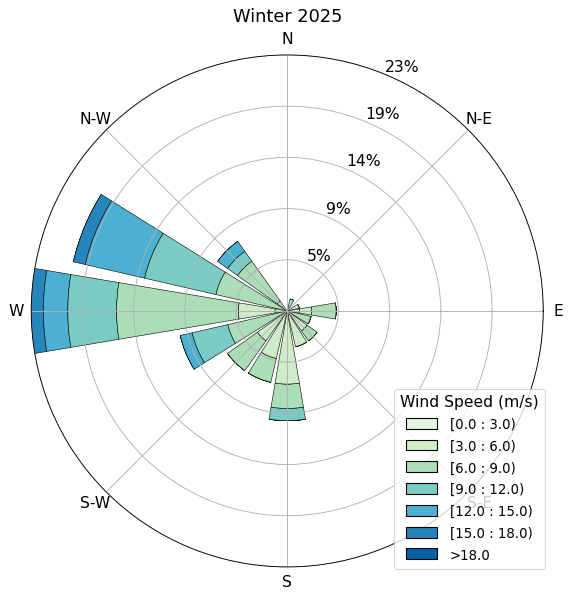

In [35]:
#WINTER 2025



ws = wind_all['2024-12-01':'2025-02-28'].resample('D').mean().wind_spd
wd = wind_all['2024-12-01':'2025-02-28'].resample('D').mean().wind_dir

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
#plt.hist([0, 1])
#plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='lower right', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Winter 2025', fontsize = 16, pad=30)

    
# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=14) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

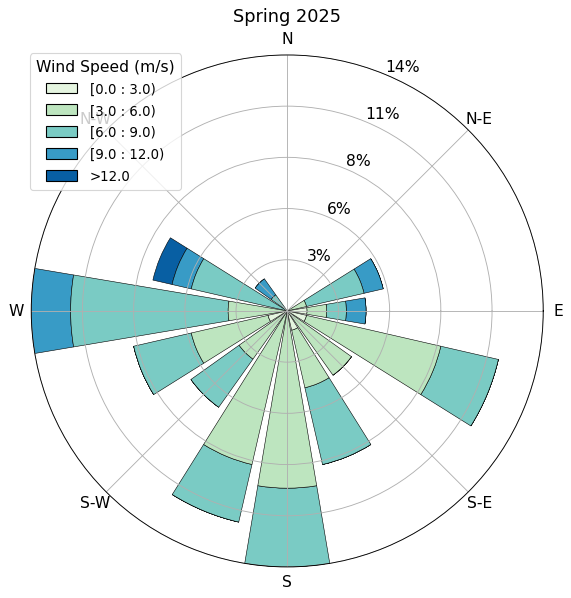

In [33]:
#SPRING 2025


ws = wind_all['2025-03-01':'2025-05-31'].resample('D').mean().wind_spd
wd = wind_all['2025-03-01':'2025-05-31'].resample('D').mean().wind_dir

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='upper left', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Spring 2025', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=14) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

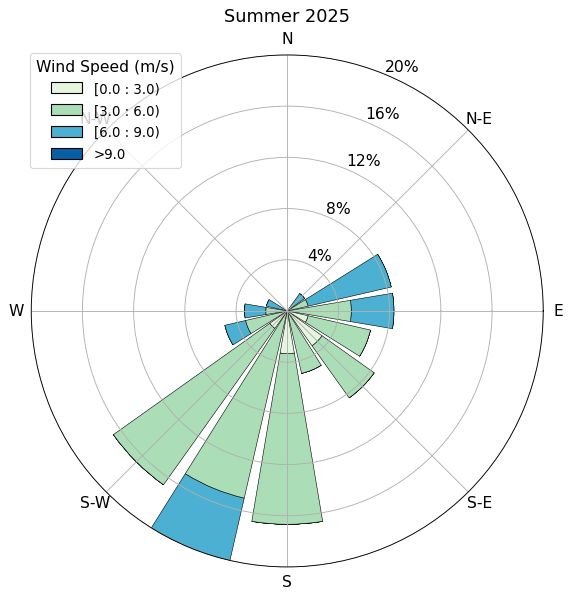

In [34]:
#SUMMER 2025


ws = wind_all['2025-06-01':'2025-07-31'].resample('D').mean().wind_spd
wd = wind_all['2025-06-01':'2025-07-31'].resample('D').mean().wind_dir

std = np.std(ws)
u = np.mean(ws)

width = 3

maxVal = round(u+4*std)
num = math.ceil((maxVal)/width)
maxVal = width*num
if maxVal > 24:
    maxVal = 24
    
dynamic = True

# Form bin ranges
if dynamic == True :
    windRange = np.arange(0, maxVal , width)
else:
    windRange = np.array([0, 3, 6, 9, 12, 15])

# Magically rounds the triangles (triangles to pizza slices if you will)
plt.hist([0, 1])
plt.close()

ax = WindroseAxes.from_ax()
ax.bar(wd, ws, bins = windRange, normed=True, opening=0.85, 
       linewidth=0.5, edgecolor='black', cmap=cmap)
ax.set_legend(title = 'Wind Speed (m/s)', loc='upper left', title_fontsize = 14, prop={'size': 14})
plt.setp(plt.gca().get_legend().get_texts(), fontsize='12')
ax.set_title('Summer 2025', fontsize = 16, pad=30)

# Format radius axis to percentages
fmt = '%.0f%%' 
yticks = mtick.FormatStrFormatter(fmt)
ax.yaxis.set_major_formatter(yticks)
plt.rc('font', size=14) # controls default text sizes
plt.rc('axes', titlesize=14) # fontsize of the axes title
plt.rc('axes', labelsize=14) # fontsize of the x and y labels
plt.rc('xtick', labelsize=14) # fontsize of the tick labels
plt.rc('ytick', labelsize=14) # fontsize of the tick labels

plt.show()

In [38]:
wind_all['u'] = -1* wind_all.wind_spd.values * np.sin(np.radians(wind_all.wind_dir.values))
wind_all['v'] = -1* wind_all.wind_spd.values * np.cos(np.radians(wind_all.wind_dir.values))

In [39]:
wind_all['y'] = 0

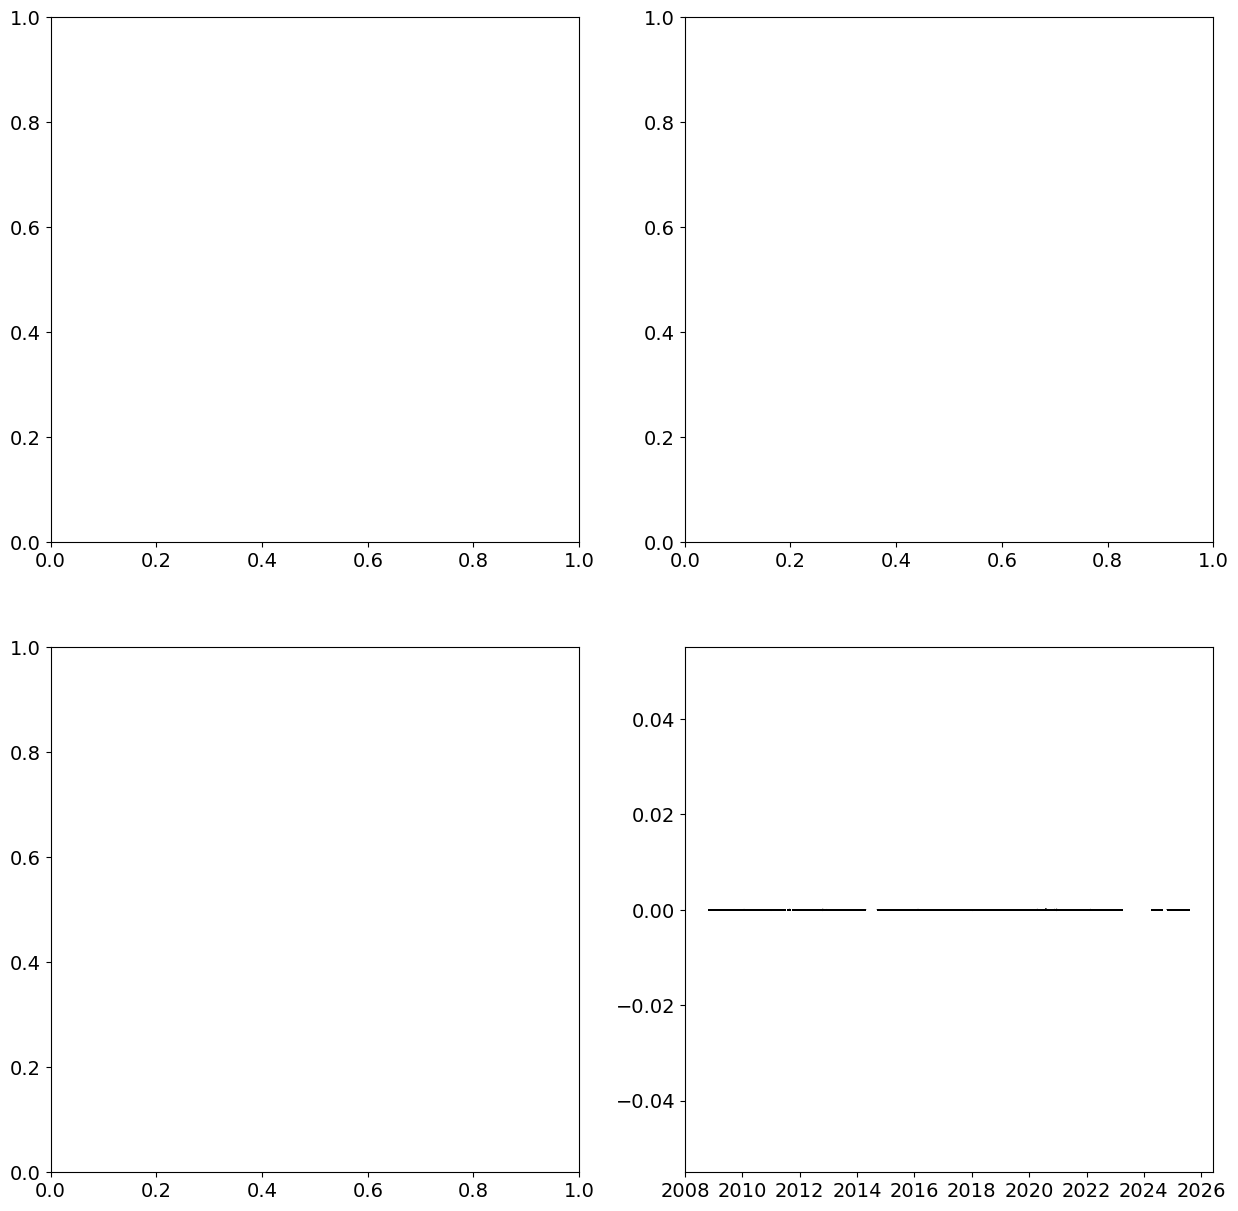

In [40]:
plt.quiver(wind_all.index, wind_all.y, wind_all.u, wind_all.v)
plt.show()

In [41]:
wind_monthly = wind_all.groupby(pn.Grouper(freq = 'M')).mean()

/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_11789/3005536065.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  wind_monthly = wind_all.groupby(pn.Grouper(freq = 'M')).mean()


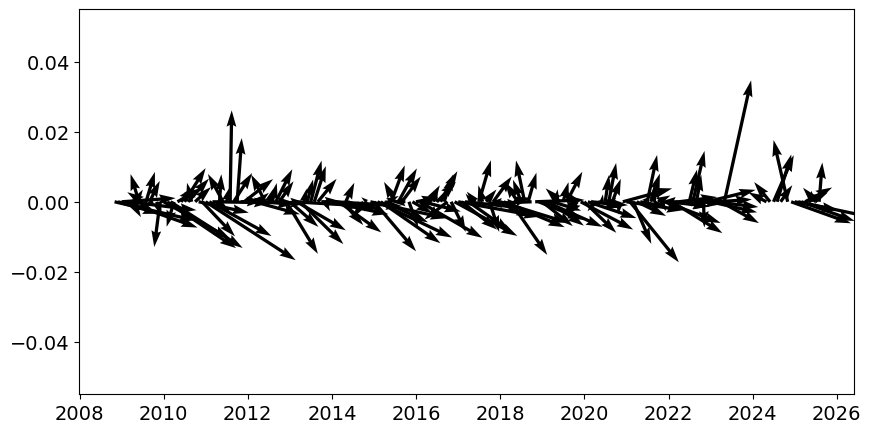

In [42]:
plt.subplots(figsize = [10,5])
plt.quiver(wind_monthly.index, wind_monthly.y, wind_monthly.u, wind_monthly.v, scale = 50)
plt.show()

In [43]:
wind_monthly['season'] = 'winter'
wind_monthly.loc[(wind_monthly.index.month >2 ) & (wind_monthly.index.month <6 ), 'season'] = 'spring'
wind_monthly.loc[(wind_monthly.index.month >5 ) & (wind_monthly.index.month <9 ), 'season'] = 'summer'
wind_monthly.loc[(wind_monthly.index.month >8 ) & (wind_monthly.index.month <12 ), 'season'] = 'fall'

In [44]:
wind_monthly.loc[(wind_monthly.index.month >2 ) & (wind_monthly.index.month <6 ), 'season'] = 'spring'

In [45]:
wind_monthly['year'] = wind_monthly.index.year

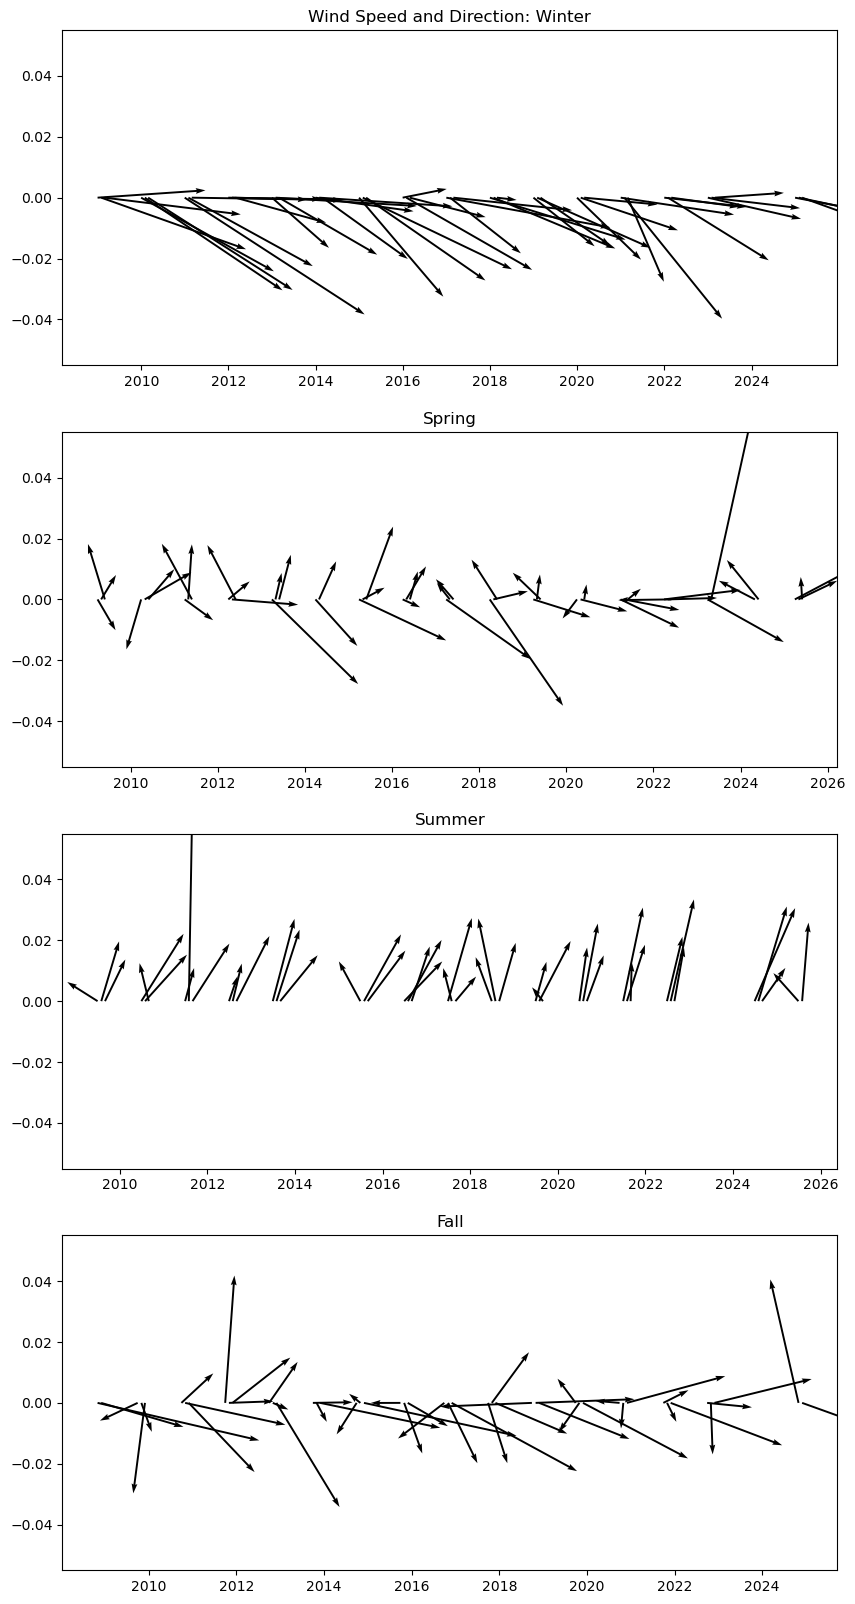

In [121]:
fig, ax = plt.subplots(nrows = 4, figsize = [10,20])

winter_wind = wind_monthly[wind_monthly.season == 'winter']
ax[0].quiver(winter_wind.index, winter_wind.y, winter_wind.u, winter_wind.v, scale = 25, width = 0.0025)
ax[0].set_title('Wind Speed and Direction: Winter')

spring_wind = wind_monthly[wind_monthly.season == 'spring']
ax[1].quiver(spring_wind.index, spring_wind.y, spring_wind.u, spring_wind.v, scale = 25, width = 0.0025)
ax[1].set_title('Spring')

summer_wind = wind_monthly[wind_monthly.season == 'summer']
ax[2].quiver(summer_wind.index, summer_wind.y, summer_wind.u, summer_wind.v, scale = 25, width = 0.0025)
ax[2].set_title('Summer')

fall_wind = wind_monthly[wind_monthly.season == 'fall']
ax[3].quiver(fall_wind.index, fall_wind.y, fall_wind.u, fall_wind.v, scale = 25, width = 0.0025)
ax[3].set_title('Fall')


plt.show()

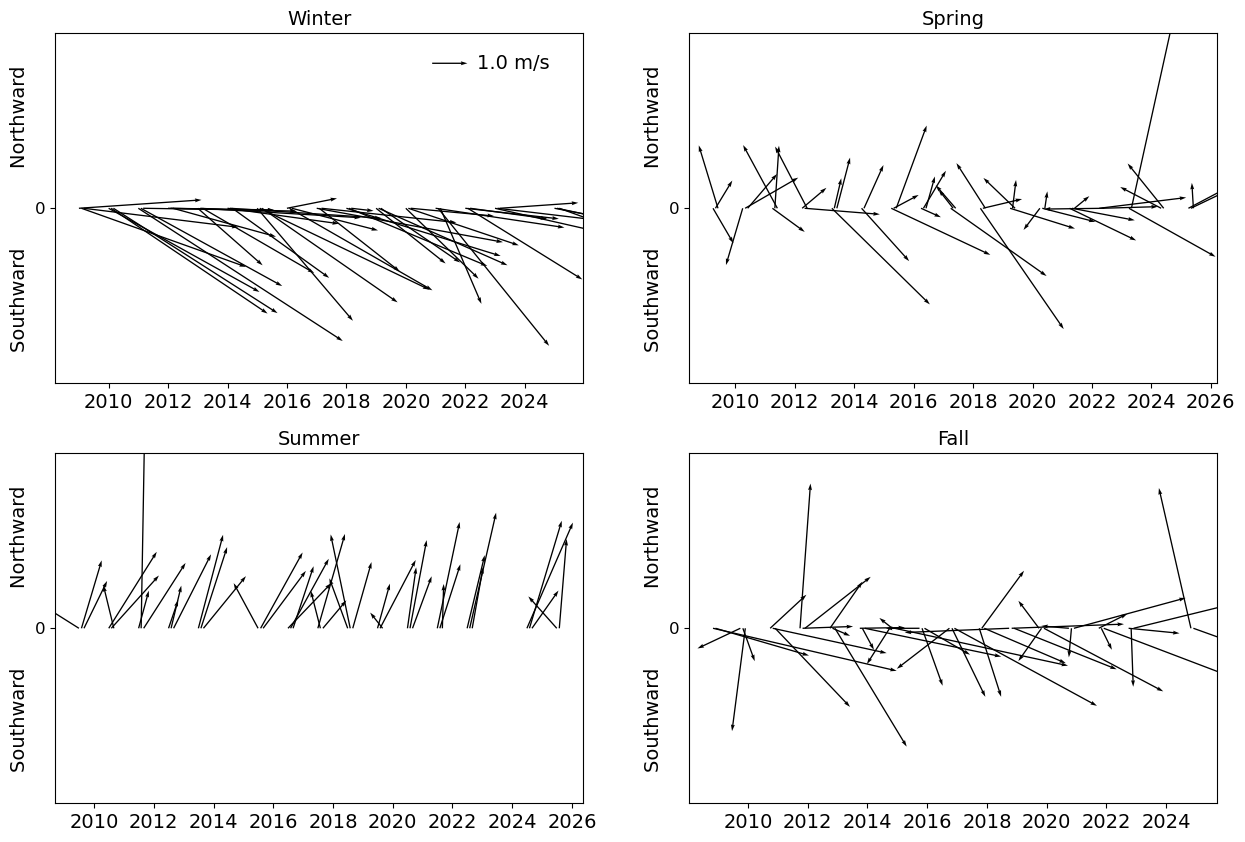

In [86]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = [15,10])

winter_wind = wind_monthly[wind_monthly.season == 'winter']
Q = ax[0,0].quiver(winter_wind.index, winter_wind.y, winter_wind.u, winter_wind.v, scale = 15, width = 0.0025)
ax[0,0].set_title('Winter')

# 1. Define tick locations
ax[0,0].set_yticks([0])

# 2. Define custom labels for those locations
ax[0,0].set_yticklabels(['0'], fontsize=12)#, color='blue')
ax[0,0].set_ylabel('Southward             Northward')

spring_wind = wind_monthly[wind_monthly.season == 'spring']
ax[0,1].quiver(spring_wind.index, spring_wind.y, spring_wind.u, spring_wind.v, scale = 15, width = 0.0025)
ax[0,1].set_title('Spring')


# 1. Define tick locations
ax[0,1].set_yticks([0])

# 2. Define custom labels for those locations
ax[0,1].set_yticklabels(['0'], fontsize=12)#, color='blue')
ax[0,1].set_ylabel('Southward             Northward')

summer_wind = wind_monthly[wind_monthly.season == 'summer']
ax[1,0].quiver(summer_wind.index, summer_wind.y, summer_wind.u, summer_wind.v, scale = 15, width = 0.0025)
ax[1,0].set_title('Summer')

# 1. Define tick locations
ax[1,0].set_yticks([0])

# 2. Define custom labels for those locations
ax[1,0].set_yticklabels(['0'], fontsize=12)#, color='blue')
ax[1,0].set_ylabel('Southward             Northward')

fall_wind = wind_monthly[wind_monthly.season == 'fall']
ax[1,1].quiver(fall_wind.index, fall_wind.y, fall_wind.u, fall_wind.v, scale = 15, width = 0.0025)
ax[1,1].set_title('Fall')


# 1. Define tick locations
ax[1,1].set_yticks([0])

# 2. Define custom labels for those locations
ax[1,1].set_yticklabels(['0'], fontsize=12)#, color='blue')
ax[1,1].set_ylabel('Southward             Northward')

plt.quiverkey(Q, 0.4,0.85, U=1, label='1.0 m/s', labelpos='E', coordinates='figure')
plt.show()

In [109]:
wind_monthly[wind_monthly.season == 'winter']

,wind_dir,wind_spd,u,v,y,season,year
time,,,,,,,
2008-12-31,218.336927,8.408895,3.479723,0.237264,0.0,winter,2008
2009-01-31,252.979812,7.859085,4.670707,-1.663372,0.0,winter,2009
2009-02-28,242.143070,7.920864,4.392196,-0.539978,0.0,winter,2009
2009-12-31,238.783491,9.388227,4.282340,-2.375239,0.0,winter,2009
2010-01-31,245.498641,7.982337,4.440876,-2.988561,0.0,winter,2010
2010-02-28,246.829085,8.609895,4.659234,-2.976620,0.0,winter,2010
2010-12-31,269.020161,9.569086,5.803704,-3.767366,0.0,winter,2010
2011-01-31,242.923284,7.287079,4.012682,-2.207534,0.0,winter,2011
2011-02-28,228.551570,7.652765,3.729528,-0.058531,0.0,winter,2011
